In [1]:
!pip install -q yfinance

import pandas as pd
import yfinance as yf

ETF	Exposure,
SHY	Short-term Treasuries,
IEF	Intermediate Treasuries,
TLT	Long-term Treasuries,
LQD	Investment-grade corporate bonds,
HYG	High-yield corporate bonds,
MUB	Municipal bonds,
AGG	Benchmark only

In [2]:
# ETFs included in the optimized portfolio
INVESTABLE_ETFS = ["SHY", "IEF", "TLT", "LQD", "HYG", "MUB"]

# Benchmark only
BENCHMARK_ETF = "AGG"

ALL_TICKERS = INVESTABLE_ETFS + [BENCHMARK_ETF]

# End date is exclusive, so this downloads through August 31, 2026
START_DATE = "2010-01-01"
END_DATE = "2026-09-01"

In [3]:
raw_data = yf.download(
    tickers=ALL_TICKERS,
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=False,
    actions=False,
    progress=False,
    group_by="column",
    threads=True
)

adjusted_prices = raw_data["Adj Close"].copy()

# setting columns in the desired order
adjusted_prices = adjusted_prices.reindex(columns=ALL_TICKERS)

# Ensuring dates are ordered
adjusted_prices = adjusted_prices.sort_index()

display(adjusted_prices.head())

Ticker,SHY,IEF,TLT,LQD,HYG,MUB,AGG
Date,,,,,,,
2010-01-04,65.232651,60.931835,55.281849,56.984287,34.073811,66.210640,64.748535
2010-01-05,65.311165,61.199348,55.638863,57.256393,34.235466,66.281425,65.043083
2010-01-06,65.318993,60.952423,54.894093,57.087696,34.324001,66.184914,65.005539
2010-01-07,65.303268,60.952423,54.986408,57.158493,34.462566,66.262146,64.930260
2010-01-08,65.366066,61.027828,54.961784,57.283627,34.516453,66.274979,64.967880


Data Validation

In [4]:
if adjusted_prices.empty:
    raise ValueError("No price data was downloaded.")

fully_missing_tickers = adjusted_prices.columns[
    adjusted_prices.isna().all()
].tolist()

if fully_missing_tickers:
    raise ValueError(
        f"No data was downloaded for: {fully_missing_tickers}"
    )

data_summary = pd.DataFrame({
    "First Date": [
        adjusted_prices[ticker].first_valid_index()
        for ticker in ALL_TICKERS
    ],
    "Last Date": [
        adjusted_prices[ticker].last_valid_index()
        for ticker in ALL_TICKERS
    ],
    "Observations": adjusted_prices.notna().sum(),
    "Missing Values": adjusted_prices.isna().sum()
})

display(data_summary)

print("Dataset shape:", adjusted_prices.shape)
print("\nMost recent prices:")
display(adjusted_prices.tail())

,First Date,Last Date,Observations,Missing Values
Ticker,,,,
SHY,2010-01-04,2026-08-31,4189,0
IEF,2010-01-04,2026-08-31,4189,0
TLT,2010-01-04,2026-08-31,4189,0
LQD,2010-01-04,2026-08-31,4189,0
HYG,2010-01-04,2026-08-31,4189,0
MUB,2010-01-04,2026-08-31,4189,0
AGG,2010-01-04,2026-08-31,4189,0


Dataset shape: (4189, 7)

Most recent prices:


Ticker,SHY,IEF,TLT,LQD,HYG,MUB,AGG
Date,,,,,,,
2026-08-24,82.000000,93.010002,82.559998,106.180000,79.699997,105.410004,97.550003
2026-08-25,82.080002,93.510002,83.470001,106.860001,79.919998,105.580002,98.010002
2026-08-26,82.050003,93.320000,83.300003,106.779999,79.900002,105.449997,97.860001
2026-08-27,82.040001,93.230003,83.129997,106.730003,79.870003,105.389999,97.830002
2026-08-31,81.889999,92.739998,82.519997,106.209999,79.809998,105.099998,97.410004


Keeping only common trading days


In [5]:
adjusted_prices = adjusted_prices.dropna(how="any")

print("Clean dataset shape:", adjusted_prices.shape)
print(
    f"Common date range: {adjusted_prices.index.min().date()} "
    f"to {adjusted_prices.index.max().date()}"
)

display(adjusted_prices.head())

Clean dataset shape: (4189, 7)
Common date range: 2010-01-04 to 2026-08-31


Ticker,SHY,IEF,TLT,LQD,HYG,MUB,AGG
Date,,,,,,,
2010-01-04,65.232651,60.931835,55.281849,56.984287,34.073811,66.210640,64.748535
2010-01-05,65.311165,61.199348,55.638863,57.256393,34.235466,66.281425,65.043083
2010-01-06,65.318993,60.952423,54.894093,57.087696,34.324001,66.184914,65.005539
2010-01-07,65.303268,60.952423,54.986408,57.158493,34.462566,66.262146,64.930260
2010-01-08,65.366066,61.027828,54.961784,57.283627,34.516453,66.274979,64.967880


## Part 2: Calculate Daily Returns and Create the Train–Test Split

We calculate the simple daily return for ETF \(i\) on trading day \(t\) as:

$$
r_{i,t}=\frac{P_{i,t}}{P_{i,t-1}}-1
$$

where \(P_{i,t}\) is the adjusted closing price of ETF \(i\) on day \(t\). Simple returns are appropriate because a portfolio’s daily return can be calculated as the weighted sum of its individual asset returns:

$$
r_{p,t}=\sum_{i=1}^{N} w_i r_{i,t}
$$

After calculating returns, the first observation is removed because no preceding price is available for computing its return.

To evaluate the portfolio out of sample, the return data are divided chronologically:

* **Training set:** First 75% of observations
* **Testing set:** Remaining 25% of observations

If \(T\) is the total number of daily return observations and

$$
k=\lfloor 0.75T \rfloor,
$$

then the two datasets are defined as:

$$
R_{\text{train}} = R_{1:k}
$$

$$
R_{\text{test}} = R_{k+1:T}
$$

The training period will be used to estimate expected returns and the covariance matrix and to construct the optimized portfolio. The testing period will remain unseen during optimization and will be used to evaluate out-of-sample performance.

The observations are not shuffled because doing so would break their time ordering and introduce look-ahead bias. The six portfolio ETFs are used in the optimization, while AGG is retained only as a benchmark.


In [6]:
daily_returns = (
    adjusted_prices
    .pct_change(fill_method=None)
    .dropna(how="any")
)

# Preserve the intended column order
daily_returns = daily_returns.reindex(columns=ALL_TICKERS)

print("Return dataset shape:", daily_returns.shape)
display(daily_returns.head())

Return dataset shape: (4188, 7)


Ticker,SHY,IEF,TLT,LQD,HYG,MUB,AGG
Date,,,,,,,
2010-01-05,0.001204,0.004390,0.006458,0.004775,0.004744,0.001069,0.004549
2010-01-06,0.000120,-0.004035,-0.013386,-0.002946,0.002586,-0.001456,-0.000577
2010-01-07,-0.000241,0.000000,0.001682,0.001240,0.004037,0.001167,-0.001158
2010-01-08,0.000962,0.001237,-0.000448,0.002189,0.001564,0.000194,0.000579
2010-01-11,0.000482,0.000674,-0.005488,0.001045,-0.000893,0.000000,-0.000772


The values are decimals:

0.001 means a return of 0.10%
-0.005 means a return of -0.50%

In [8]:
#Cronological Split
TRAIN_FRACTION = 0.75

number_of_observations = len(daily_returns)
split_index = int(number_of_observations * TRAIN_FRACTION)

train_returns = daily_returns.iloc[:split_index].copy()
test_returns = daily_returns.iloc[split_index:].copy()

This uses the first 75% of observations for training and the remaining 25% for testing. Nothing is shuffled.

In [9]:
#Validating the split

assert len(train_returns) + len(test_returns) == len(daily_returns)
assert train_returns.index.max() < test_returns.index.min()

split_summary = pd.DataFrame({
    "Period": ["Training", "Testing"],
    "Observations": [len(train_returns), len(test_returns)],
    "Percentage": [
        len(train_returns) / len(daily_returns),
        len(test_returns) / len(daily_returns)
    ],
    "Start Date": [
        train_returns.index.min().date(),
        test_returns.index.min().date()
    ],
    "End Date": [
        train_returns.index.max().date(),
        test_returns.index.max().date()
    ]
})

split_summary["Percentage"] = split_summary["Percentage"].map(
    lambda value: f"{value:.2%}"
)

display(split_summary)

,Period,Observations,Percentage,Start Date,End Date
0,Training,3141,75.00%,2010-01-05,2022-06-27
1,Testing,1047,25.00%,2022-06-28,2026-08-31


Separating optimization assets from AGG

In [10]:
# Six ETFs that Gurobi will be allowed to allocate to
train_asset_returns = train_returns[INVESTABLE_ETFS].copy()
test_asset_returns = test_returns[INVESTABLE_ETFS].copy()

# AGG is retained only as the benchmark
test_agg_returns = test_returns[BENCHMARK_ETF].copy()

print("Optimization assets:", train_asset_returns.columns.tolist())
print("Benchmark:", test_agg_returns.name)

print("\nTraining observations:", len(train_asset_returns))
print("Testing observations:", len(test_asset_returns))

Optimization assets: ['SHY', 'IEF', 'TLT', 'LQD', 'HYG', 'MUB']
Benchmark: AGG

Training observations: 3141
Testing observations: 1047


Now to estimate annualized expected returns and the annualized covariance matrix from train_asset_returns only.

Using only the training data, estimate:

$$ \hat{\mu}=252\bar{r}_{\text{train}} $$ $$ \hat{\Sigma}=252\operatorname{Cov}(r_{\text{train}}) $$

We use 252 as the approximate number of trading days per year.

In [11]:
#Estimating annualized inputs

import numpy as np

TRADING_DAYS = 252

# Historical arithmetic mean return
annual_expected_returns = (
    train_asset_returns.mean() * TRADING_DAYS
)

# Historical sample covariance matrix
annual_covariance = (
    train_asset_returns.cov() * TRADING_DAYS
)

The expected-return vector contains one value per ETF:

In [12]:
display(
    annual_expected_returns
    .rename("Annualized Expected Return")
    .to_frame()
    .style.format("{:.2%}")
)

,Annualized Expected Return
Ticker,
SHY,0.78%
IEF,3.10%
TLT,5.45%
LQD,4.05%
HYG,4.70%
MUB,2.91%


Examining return and risk estimates

In [13]:
annual_volatility = pd.Series(
    np.sqrt(np.diag(annual_covariance)),
    index=INVESTABLE_ETFS,
    name="Annualized Volatility"
)

asset_statistics = pd.concat(
    [annual_expected_returns, annual_volatility],
    axis=1
)

asset_statistics.columns = [
    "Annualized Expected Return",
    "Annualized Volatility"
]

display(asset_statistics.style.format("{:.2%}"))

,Annualized Expected Return,Annualized Volatility
SHY,0.78%,1.02%
IEF,3.10%,6.21%
TLT,5.45%,14.81%
LQD,4.05%,7.30%
HYG,4.70%,8.54%
MUB,2.91%,4.98%


The above are historical estimates, not guaranteed future returns. The expected returns will usually be less stable than the volatility estimates.

In [14]:
#Display the covariance matrix

display(
    annual_covariance.style
    .format("{:.6f}")
    .set_caption("Annualized Covariance Matrix")
)

Ticker,SHY,IEF,TLT,LQD,HYG,MUB
Ticker,,,,,,
SHY,0.000103,0.000466,0.000861,0.000347,-0.000061,0.000149
IEF,0.000466,0.003852,0.008456,0.002826,-0.001079,0.001121
TLT,0.000861,0.008456,0.021933,0.006496,-0.003207,0.002445
LQD,0.000347,0.002826,0.006496,0.005327,0.002098,0.002089
HYG,-0.000061,-0.001079,-0.003207,0.002098,0.007297,0.001089
MUB,0.000149,0.001121,0.002445,0.002089,0.001089,0.002479


The diagonal entries above represent each ETF’s variance. The off-diagonal entries describe how pairs of ETF returns move together.

In [15]:
#Convert inputs for Gurobi

assets = INVESTABLE_ETFS.copy()

mu = annual_expected_returns.loc[assets].to_numpy()

Sigma = (
    annual_covariance
    .loc[assets, assets]
    .to_numpy()
)

print("Asset order:", assets)
print("Expected-return vector shape:", mu.shape)
print("Covariance matrix shape:", Sigma.shape)

Asset order: ['SHY', 'IEF', 'TLT', 'LQD', 'HYG', 'MUB']
Expected-return vector shape: (6,)
Covariance matrix shape: (6, 6)


Validate the covariance matrix

In [16]:
assert mu.shape == (6,)
assert Sigma.shape == (6, 6)
assert np.allclose(Sigma, Sigma.T)

eigenvalues = np.linalg.eigvalsh(Sigma)
minimum_eigenvalue = eigenvalues.min()

print("Minimum covariance eigenvalue:", minimum_eigenvalue)

if minimum_eigenvalue < -1e-10:
    raise ValueError("The covariance matrix is not positive semidefinite.")

print("Model inputs are ready for optimization.")

Minimum covariance eigenvalue: 3.71314359799007e-05
Model inputs are ready for optimization.


A positive-semidefinite covariance matrix ensures that portfolio variance,

$$ w^\top\Sigma w, $$

is a convex quadratic expression.

Only train_asset_returns was used here. Neither the test-period returns nor AGG influenced the estimates. The next part is the Gurobi quadratic portfolio model with the allocation, HYG, and Treasury constraints.

In [17]:
# now th egurobi optimization model

## Part 4: Build the Gurobi Quadratic Optimization Model

The model is:

$$
\max_w \quad \mu^\top w-\lambda w^\top\Sigma w
$$

where:

- $\mu^\top w$ is expected annual return.
- $w^\top\Sigma w$ is annual portfolio variance.
- $\lambda$ controls risk aversion.

We’ll start with $\lambda=5$. A larger value produces a more conservative portfolio.

In [18]:
!pip install -q gurobipy

import gurobipy as gp
from gurobipy import GRB

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 68.0 MB/s eta 0:00:00


In [19]:
#setting the risk-aversion parameter

RISK_AVERSION = 5.0

#Model and decision variables

model = gp.Model("fixed_income_etf_portfolio")

weights = model.addVars(
    assets,
    lb=0.0,
    ub=0.35,
    vtype=GRB.CONTINUOUS,
    name="weight"
)

Restricted license - for non-production use only - expires 2027-11-29


The decision variable weights[asset] represents the fraction of the portfolio invested in that ETF.

The variable bounds enforce:

$$
0 \leq w_i \leq 0.35
$$

In [20]:
#Objective function

expected_return_expression = gp.quicksum(
    float(annual_expected_returns.loc[asset]) * weights[asset]
    for asset in assets
)

portfolio_variance_expression = gp.quicksum(
    float(annual_covariance.loc[asset_i, asset_j])
    * weights[asset_i]
    * weights[asset_j]
    for asset_i in assets
    for asset_j in assets
)

model.setObjective(
    expected_return_expression
    - RISK_AVERSION * portfolio_variance_expression,
    GRB.MAXIMIZE
)

In [21]:
#Portfolio constraints

# Fully invested portfolio
model.addConstr(
    gp.quicksum(weights[asset] for asset in assets) == 1.0,
    name="fully_invested"
)

# High-yield exposure cannot exceed 20%
model.addConstr(
    weights["HYG"] <= 0.20,
    name="high_yield_limit"
)

# At least 30% must be allocated to Treasury ETFs
TREASURY_ETFS = ["SHY", "IEF", "TLT"]

model.addConstr(
    gp.quicksum(weights[asset] for asset in TREASURY_ETFS) >= 0.30,
    name="minimum_treasury_allocation"
)

<gurobi.Constr *Awaiting Model Update*>

The model now contains all four required restrictions:

$$
\sum_i w_i = 1
$$

$$
0 \leq w_i \leq 0.35
$$

$$
w_{\mathrm{HYG}} \leq 0.20
$$

$$
w_{\mathrm{SHY}} + w_{\mathrm{IEF}} + w_{\mathrm{TLT}} \geq 0.30
$$

In [22]:
#Solving the model

model.optimize()

if model.Status != GRB.OPTIMAL:
    raise RuntimeError(
        f"Gurobi did not find an optimal solution. Status: {model.Status}"
    )

print("Optimal solution found.")

Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 3 rows, 6 columns and 10 nonzeros (Max)
Model fingerprint: 0xd72f61c8
Model has 6 linear objective coefficients
Model has 21 quadratic objective terms
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [8e-03, 5e-02]
  QObjective range [1e-03, 2e-01]
  Bounds range     [3e-01, 3e-01]
  RHS range        [2e-01, 1e+00]

Presolve removed 1 rows and 0 columns
Presolve time: 0.01s
Presolved: 2 rows, 6 columns, 9 nonzeros
Presolved model has 21 quadratic objective terms
Ordering time: 0.00s

Barrier statistics:
 Free vars  : 5
 AA' NZ     : 2.100e+01
 Factor NZ  : 2.800e+01
 Factor Ops : 1.400e+02 (less than 1 second per iteration)
 Threads    : 1

                  Objective                Residual
Iter       Pri

Extracting optimized weights


In [23]:
optimized_weights = pd.Series(
    {
        asset: weights[asset].X
        for asset in assets
    },
    index=assets,
    name="Optimized Weight"
)

# Remove tiny numerical values such as 1e-10
optimized_weights[
    optimized_weights.abs() < 1e-8
] = 0.0

display(
    optimized_weights
    .to_frame()
    .style.format("{:.2%}")
)

,Optimized Weight
SHY,0.00%
IEF,27.62%
TLT,4.02%
LQD,13.64%
HYG,20.00%
MUB,34.72%


Verifying constraints

In [24]:
constraint_summary = pd.Series({
    "Total allocation": optimized_weights.sum(),
    "Largest ETF allocation": optimized_weights.max(),
    "HYG allocation": optimized_weights["HYG"],
    "Treasury allocation": optimized_weights[TREASURY_ETFS].sum()
})

display(
    constraint_summary
    .rename("Value")
    .to_frame()
    .style.format("{:.2%}")
)

,Value
Total allocation,100.00%
Largest ETF allocation,34.72%
HYG allocation,20.00%
Treasury allocation,31.64%


Formal Checks

In [25]:
TOLERANCE = 1e-6

assert np.isclose(
    optimized_weights.sum(),
    1.0,
    atol=TOLERANCE
)

assert (optimized_weights >= -TOLERANCE).all()

assert (
    optimized_weights <= 0.35 + TOLERANCE
).all()

assert optimized_weights["HYG"] <= 0.20 + TOLERANCE

assert (
    optimized_weights[TREASURY_ETFS].sum()
    >= 0.30 - TOLERANCE
)

print("All portfolio constraints are satisfied.")

All portfolio constraints are satisfied.


Calculating the estimated portfolio characteristics

In [26]:
w_opt = optimized_weights.loc[assets].to_numpy()

estimated_annual_return = float(mu @ w_opt)

estimated_annual_variance = float(
    w_opt @ Sigma @ w_opt
)

estimated_annual_volatility = np.sqrt(
    estimated_annual_variance
)

print(
    f"Estimated annual return: "
    f"{estimated_annual_return:.2%}"
)

print(
    f"Estimated annual volatility: "
    f"{estimated_annual_volatility:.2%}"
)

print(
    f"Objective value: "
    f"{model.ObjVal:.6f}"
)

Estimated annual return: 3.58%
Estimated annual volatility: 4.55%
Objective value: 0.025444


Creating equal weights

In [27]:
equal_weights = pd.Series(
    1.0 / len(assets),
    index=assets,
    name="Equal Weight"
)

weight_comparison = pd.concat(
    [optimized_weights, equal_weights],
    axis=1
)

display(weight_comparison.style.format("{:.2%}"))

,Optimized Weight,Equal Weight
SHY,0.00%,16.67%
IEF,27.62%,16.67%
TLT,4.02%,16.67%
LQD,13.64%,16.67%
HYG,20.00%,16.67%
MUB,34.72%,16.67%


Each ETF receives:

$$ \frac{1}{6}=16.67\% $$

in the equal-weight portfolio.

In [28]:
#Defining a buy-and-hold backtest function

def calculate_buy_and_hold_returns(
    asset_returns,
    initial_weights
):
    """
    Calculate portfolio returns when weights are assigned at
    the beginning and no rebalancing occurs afterward.
    """

    weights_aligned = initial_weights.reindex(
        asset_returns.columns
    )

    if weights_aligned.isna().any():
        raise ValueError(
            "Portfolio weights do not match the ETF columns."
        )

    if not np.isclose(weights_aligned.sum(), 1.0):
        raise ValueError(
            "Portfolio weights must sum to one."
        )

    # Growth of $1 invested separately in each ETF
    asset_growth = (1.0 + asset_returns).cumprod()

    # Initial capital assigned according to portfolio weights
    portfolio_value = (
        asset_growth
        .mul(weights_aligned, axis="columns")
        .sum(axis=1)
    )

    # Convert the portfolio value series back into daily returns
    portfolio_returns = portfolio_value.pct_change(
        fill_method=None
    )

    # Return on the first test day relative to initial value of $1
    portfolio_returns.iloc[0] = (
        portfolio_value.iloc[0] - 1.0
    )

    return portfolio_returns, portfolio_value

Running the optimized portfolio backtest

In [29]:
optimized_test_returns, optimized_portfolio_value = (
    calculate_buy_and_hold_returns(
        test_asset_returns,
        optimized_weights
    )
)

Running the equal-weight portfolio backtest

In [30]:
equal_weight_test_returns, equal_weight_portfolio_value = (
    calculate_buy_and_hold_returns(
        test_asset_returns,
        equal_weights
    )
)

Combineing all three return series

In [31]:
out_of_sample_returns = pd.DataFrame({
    "Optimized Portfolio": optimized_test_returns,
    "Equal-Weight Portfolio": equal_weight_test_returns,
    "AGG Benchmark": test_agg_returns
})

assert not out_of_sample_returns.isna().any().any()

print("Test-period date range:")
print(
    out_of_sample_returns.index.min().date(),
    "to",
    out_of_sample_returns.index.max().date()
)

print("\nNumber of test observations:")
print(len(out_of_sample_returns))

display(out_of_sample_returns.head())

Test-period date range:
2022-06-28 to 2026-08-31

Number of test observations:
1047


,Optimized Portfolio,Equal-Weight Portfolio,AGG Benchmark
Date,,,
2022-06-28,-0.002185,-0.001163,0.000397
2022-06-29,0.004631,0.005511,0.005764
2022-06-30,0.004177,0.004168,0.004544
2022-07-01,0.008371,0.008361,0.008335
2022-07-05,0.001973,0.002143,0.001857


Calculating cumulative growth

In [32]:
cumulative_growth = (
    1.0 + out_of_sample_returns
).cumprod()

display(cumulative_growth.tail())

,Optimized Portfolio,Equal-Weight Portfolio,AGG Benchmark
Date,,,
2026-08-24,1.150144,1.120347,1.122352
2026-08-25,1.154504,1.125250,1.127645
2026-08-26,1.153163,1.124086,1.125919
2026-08-27,1.152408,1.123310,1.125574
2026-08-31,1.148548,1.119325,1.120742


The values above show how an initial investment of $1 grew during the test period.

In [33]:
ending_values = (
    cumulative_growth
    .iloc[-1]
    .rename("Ending Value of $1")
    .to_frame()
)

display(ending_values.style.format("${:.3f}"))

,Ending Value of $1
Optimized Portfolio,$1.149
Equal-Weight Portfolio,$1.119
AGG Benchmark,$1.121


For example, an ending value of 1.08 means the portfolio produced an 8% cumulative return over the test period.

No test-period returns were used to estimate or modify the optimized weights. The next part is to calculate annualized return, annualized volatility, Sharpe ratio, maximum drawdown, and tracking error versus AGG.

In [34]:
#performance metrics

Calculate out-of-sample performance metrics

We’ll report:

Annualized return,
Annualized volatility,
Sharpe ratio,
Maximum drawdown,
Tracking error versus AGG

For simplicity, we’ll assume a 0% annual risk-free rate when calculating the Sharpe ratio.

In [35]:
#Set metric assumptions

TRADING_DAYS = 252
ANNUAL_RISK_FREE_RATE = 0.0

In [36]:
#Defining the performance functions

def calculate_annualized_return(
    returns,
    trading_days=252
):
    number_of_days = len(returns)

    total_growth = (1.0 + returns).prod()

    return (
        total_growth ** (trading_days / number_of_days)
        - 1.0
    )


def calculate_annualized_volatility(
    returns,
    trading_days=252
):
    return (
        returns.std(ddof=1)
        * np.sqrt(trading_days)
    )


def calculate_sharpe_ratio(
    returns,
    annual_risk_free_rate=0.0,
    trading_days=252
):
    daily_risk_free_rate = (
        (1.0 + annual_risk_free_rate)
        ** (1.0 / trading_days)
        - 1.0
    )

    daily_excess_returns = (
        returns - daily_risk_free_rate
    )

    annualized_volatility = (
        returns.std(ddof=1)
        * np.sqrt(trading_days)
    )

    if np.isclose(annualized_volatility, 0.0):
        return np.nan

    annualized_excess_return = (
        daily_excess_returns.mean()
        * trading_days
    )

    return (
        annualized_excess_return
        / annualized_volatility
    )


def calculate_maximum_drawdown(returns):
    wealth = (1.0 + returns).cumprod()

    # Include the initial portfolio value of $1 as a peak
    running_peak = wealth.cummax().clip(lower=1.0)

    drawdown = (
        wealth / running_peak
        - 1.0
    )

    return drawdown.min()


def calculate_tracking_error(
    portfolio_returns,
    benchmark_returns,
    trading_days=252
):
    active_returns = (
        portfolio_returns - benchmark_returns
    )

    return (
        active_returns.std(ddof=1)
        * np.sqrt(trading_days)
    )

In [37]:
#Calculating the metrics

performance_summary = pd.DataFrame(
    index=out_of_sample_returns.columns
)

performance_summary["Annualized Return"] = (
    out_of_sample_returns.apply(
        calculate_annualized_return
    )
)

performance_summary["Annualized Volatility"] = (
    out_of_sample_returns.apply(
        calculate_annualized_volatility
    )
)

performance_summary["Sharpe Ratio"] = (
    out_of_sample_returns.apply(
        lambda returns: calculate_sharpe_ratio(
            returns,
            annual_risk_free_rate=ANNUAL_RISK_FREE_RATE
        )
    )
)

performance_summary["Maximum Drawdown"] = (
    out_of_sample_returns.apply(
        calculate_maximum_drawdown
    )
)

agg_benchmark_returns = out_of_sample_returns[
    "AGG Benchmark"
]

performance_summary["Tracking Error vs AGG"] = (
    out_of_sample_returns.apply(
        lambda returns: calculate_tracking_error(
            returns,
            agg_benchmark_returns
        )
    )
)

In [38]:
#Results Display

display(
    performance_summary.style.format({
        "Annualized Return": "{:.2%}",
        "Annualized Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.2f}",
        "Maximum Drawdown": "{:.2%}",
        "Tracking Error vs AGG": "{:.2%}"
    })
)

,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,Tracking Error vs AGG
Optimized Portfolio,3.39%,5.83%,0.60,-9.18%,1.66%
Equal-Weight Portfolio,2.75%,6.39%,0.46,-10.32%,1.40%
AGG Benchmark,2.78%,6.08%,0.48,-9.79%,0.00%


Validating the result

In [39]:
assert np.isclose(
    performance_summary.loc[
        "AGG Benchmark",
        "Tracking Error vs AGG"
    ],
    0.0,
    atol=1e-12
)

assert (
    performance_summary["Annualized Volatility"] >= 0
).all()

assert (
    performance_summary["Maximum Drawdown"] <= 0
).all()

print("All performance metrics calculated successfully.")

All performance metrics calculated successfully.


**How to interpret the table:**

- **Higher annualized return** is better.
- **Lower annualized volatility** means more stable returns.
- **Higher Sharpe ratio** means better return relative to risk.
- **Maximum drawdown** is negative; closer to zero is better.
- **Lower tracking error** means the portfolio behaved more similarly to AGG.
- **AGG’s tracking error** against itself should be exactly 0%.

All metrics are calculated exclusively from the out-of-sample test period.

In [40]:
#next step


The next part introduces a 100-basis-point interest-rate stress test using ETF durations.

##Running the 100-Basis-Point Rate Stress Test

For a small parallel change in yields, approximate each ETF’s price change using:

$$
\frac{\Delta P_i}{P_i} \approx -D_i\Delta y
$$

For a 100-basis-point increase:

$$
\Delta y=\frac{100}{10{,}000}=0.01
$$

Therefore, an ETF with a duration of 7 years would experience an approximate 7% price decline.

In [41]:
#Entering the effective-duration data

DURATION_AS_OF = "2026-08-31"

effective_duration = pd.Series({
    "SHY": 1.85,
    "IEF": 6.94,
    "TLT": 15.01,
    "LQD": 7.69,
    "HYG": 2.98,
    "MUB": 6.97
}, name="Effective Duration")

effective_duration = effective_duration.loc[assets]

display(
    effective_duration
    .to_frame()
    .style.format("{:.2f} years")
)

,Effective Duration
SHY,1.85 years
IEF,6.94 years
TLT,15.01 years
LQD,7.69 years
HYG,2.98 years
MUB,6.97 years


These are effective durations published by iShares as of August 31, 2026: SHY, IEF, TLT, LQD, HYG, and MUB.

Duration changes as the ETFs’ holdings and market yields change, so recording the date makes the analysis reproducible.

In [42]:
#Defining the interest-rate shock

RATE_SHOCK_BPS = 100

rate_shock_decimal = (
    RATE_SHOCK_BPS / 10_000
)

print(
    f"Interest-rate shock: "
    f"{RATE_SHOCK_BPS} basis points"
)

print(
    f"Decimal yield change: "
    f"{rate_shock_decimal:.2%}"
)

Interest-rate shock: 100 basis points
Decimal yield change: 1.00%


In [43]:
#Calculating each ETF’s price impact

stress_test_results = pd.DataFrame({
    "Optimized Weight": optimized_weights.loc[assets],
    "Effective Duration": effective_duration
})

stress_test_results["Estimated ETF Price Change"] = (
    -stress_test_results["Effective Duration"]
    * rate_shock_decimal
)

stress_test_results["Portfolio Return Contribution"] = (
    stress_test_results["Optimized Weight"]
    * stress_test_results["Estimated ETF Price Change"]
)

display(
    stress_test_results.style.format({
        "Optimized Weight": "{:.2%}",
        "Effective Duration": "{:.2f}",
        "Estimated ETF Price Change": "{:.2%}",
        "Portfolio Return Contribution": "{:.2%}"
    })
)

,Optimized Weight,Effective Duration,Estimated ETF Price Change,Portfolio Return Contribution
SHY,0.00%,1.85,-1.85%,-0.00%
IEF,27.62%,6.94,-6.94%,-1.92%
TLT,4.02%,15.01,-15.01%,-0.60%
LQD,13.64%,7.69,-7.69%,-1.05%
HYG,20.00%,2.98,-2.98%,-0.60%
MUB,34.72%,6.97,-6.97%,-2.42%


For example, TLT’s estimated price change is:

$$
-15.01(0.01)=-15.01\%
$$

Its effect on the complete portfolio depends on how much the optimizer allocated to TLT.

In [44]:
#Calculating portfolio duration and total loss

portfolio_effective_duration = float(
    optimized_weights.loc[assets]
    @ effective_duration.loc[assets]
)

stressed_portfolio_return = float(
    stress_test_results[
        "Portfolio Return Contribution"
    ].sum()
)

portfolio_loss = -stressed_portfolio_return

print(
    f"Portfolio effective duration: "
    f"{portfolio_effective_duration:.2f} years"
)

print(
    f"Estimated portfolio return under shock: "
    f"{stressed_portfolio_return:.2%}"
)

print(
    f"Estimated portfolio loss: "
    f"{portfolio_loss:.2%}"
)

Portfolio effective duration: 6.59 years
Estimated portfolio return under shock: -6.59%
Estimated portfolio loss: 6.59%


The same result can be calculated directly:

$$
\frac{\Delta V}{V}\approx-D_p(0.01)
$$

where:

$$
D_p=\sum_i w_iD_i
$$

In [45]:
#Validating the calculation

direct_duration_estimate = (
    -portfolio_effective_duration
    * rate_shock_decimal
)

assert np.isclose(
    stressed_portfolio_return,
    direct_duration_estimate
)

assert portfolio_loss >= 0

print("Rate-stress calculation validated.")

Rate-stress calculation validated.


**This is an immediate first-order price-impact estimate. It assumes:**

- All relevant yields increase by exactly 100 basis points.
- Credit spreads remain unchanged.
- Duration remains constant during the shock.
- Convexity, income, taxes, and trading effects are ignored.

In [46]:
#final charts: optimized allocations, out-of-sample cumulative growth, and rate-shock losses.

import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import PercentFormatter

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

Optimized ETF allocations

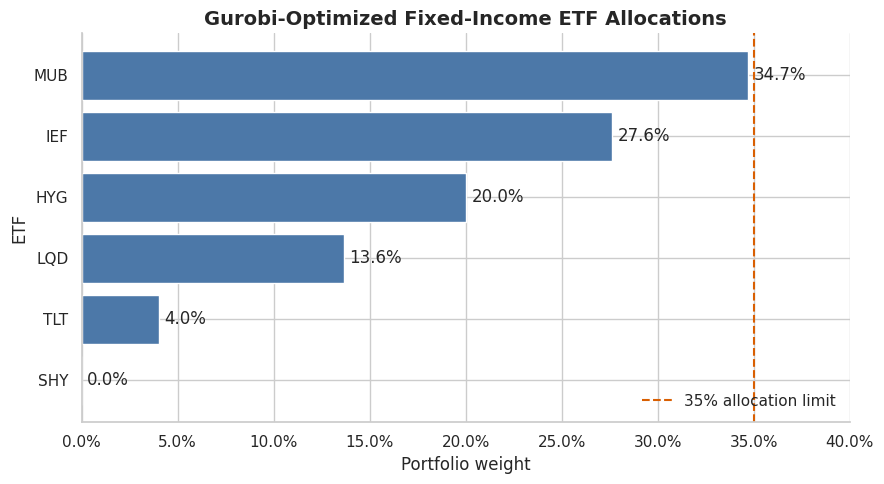

In [47]:
allocation_plot = optimized_weights.sort_values()

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    allocation_plot.index,
    allocation_plot.values,
    color="#4C78A8"
)

ax.bar_label(
    bars,
    labels=[
        f"{weight:.1%}"
        for weight in allocation_plot.values
    ],
    padding=4
)

# Show the maximum-allocation constraint
ax.axvline(
    0.35,
    color="#D95F02",
    linestyle="--",
    linewidth=1.5,
    label="35% allocation limit"
)

ax.set_title(
    "Gurobi-Optimized Fixed-Income ETF Allocations",
    fontsize=14,
    weight="bold"
)

ax.set_xlabel("Portfolio weight")
ax.set_ylabel("ETF")
ax.set_xlim(0, 0.40)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(frameon=False, loc="lower right")

sns.despine()
plt.tight_layout()

fig.savefig(
    "optimized_etf_allocations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The above chart shows the portfolio composition and whether any ETF reaches the 35% allocation limit.

In [48]:
#next chart


Out-of-sample cumulative returns

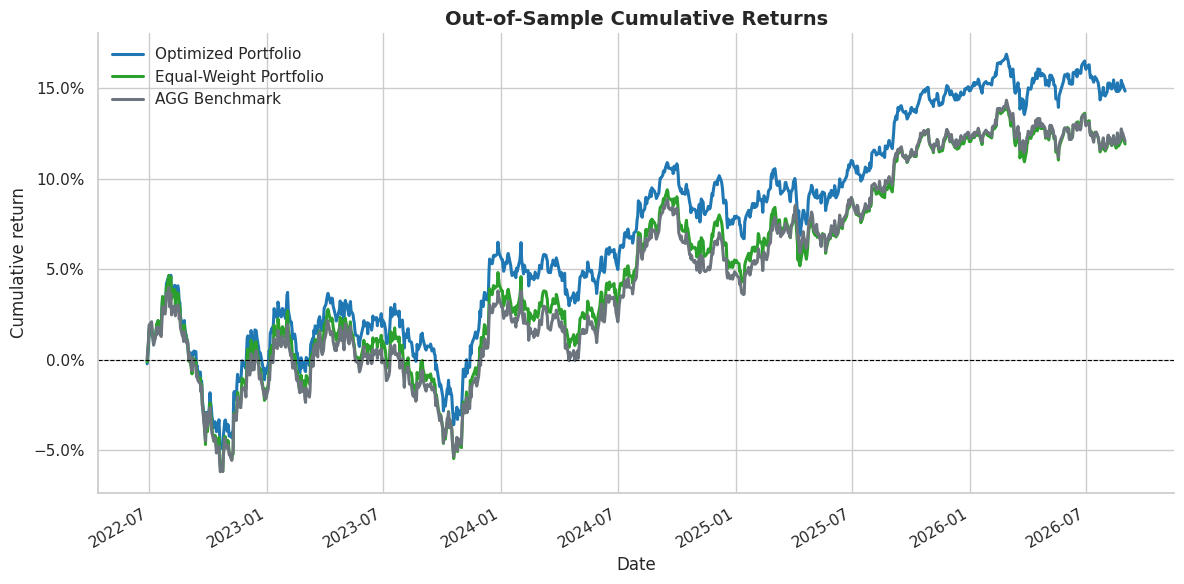

In [49]:
cumulative_returns = (
    1.0 + out_of_sample_returns
).cumprod() - 1.0

portfolio_colors = {
    "Optimized Portfolio": "#1F77B4",
    "Equal-Weight Portfolio": "#2CA02C",
    "AGG Benchmark": "#6C757D"
}

fig, ax = plt.subplots(figsize=(12, 6))

for portfolio_name in cumulative_returns.columns:
    ax.plot(
        cumulative_returns.index,
        cumulative_returns[portfolio_name],
        label=portfolio_name,
        color=portfolio_colors[portfolio_name],
        linewidth=2.2
    )

ax.axhline(
    0,
    color="black",
    linewidth=0.8,
    linestyle="--"
)

ax.set_title(
    "Out-of-Sample Cumulative Returns",
    fontsize=14,
    weight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Cumulative return")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(frameon=False)

fig.autofmt_xdate(rotation=30)
sns.despine()
plt.tight_layout()

fig.savefig(
    "out_of_sample_cumulative_returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The above chart compares the three portfolios using only the test-period returns.

In [50]:
#next chart

Loss under a 100-basis-point rate increase

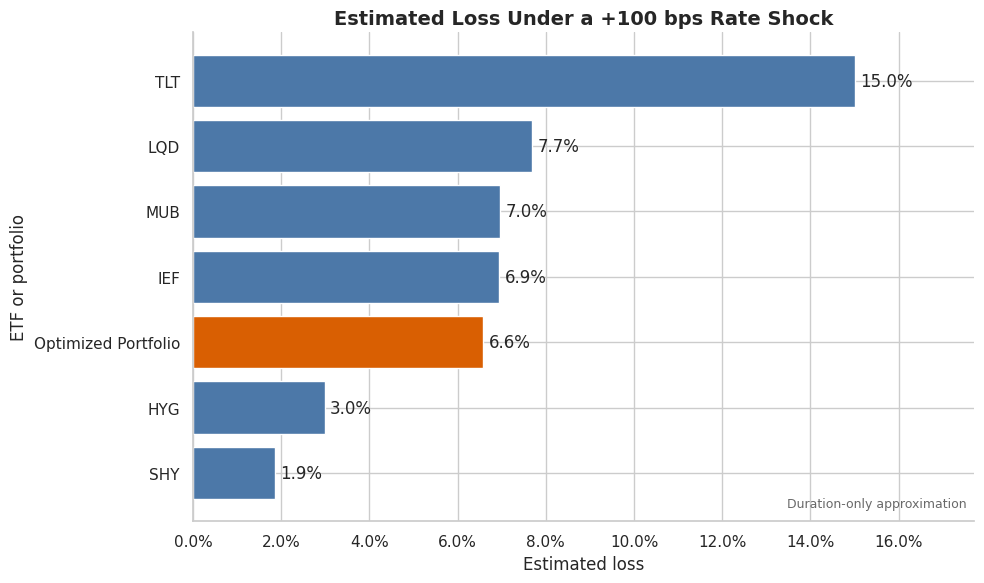

In [51]:
#Creating one series containing the estimated loss for each ETF and the complete optimized portfolio:

shock_losses = (
    -stress_test_results["Estimated ETF Price Change"]
).copy()

shock_losses.loc["Optimized Portfolio"] = portfolio_loss

shock_losses = shock_losses.sort_values()

# Ploting the results

bar_colors = [
    "#D95F02"
    if label == "Optimized Portfolio"
    else "#4C78A8"
    for label in shock_losses.index
]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    shock_losses.index,
    shock_losses.values,
    color=bar_colors
)

ax.bar_label(
    bars,
    labels=[
        f"{loss:.1%}"
        for loss in shock_losses.values
    ],
    padding=4
)

ax.set_title(
    "Estimated Loss Under a +100 bps Rate Shock",
    fontsize=14,
    weight="bold"
)

ax.set_xlabel("Estimated loss")
ax.set_ylabel("ETF or portfolio")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_xlim(
    0,
    shock_losses.max() * 1.18
)

ax.text(
    0.99,
    0.03,
    "Duration-only approximation",
    transform=ax.transAxes,
    horizontalalignment="right",
    fontsize=9,
    color="dimgray"
)

sns.despine()
plt.tight_layout()

fig.savefig(
    "rate_shock_losses.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



In the above chart, the blue bars show each ETF’s standalone estimated price loss. The orange bar shows the weighted loss for the optimized portfolio.

In [52]:
#Consolidating the final results

# Final results summary for interpretation

print("=" * 65)
print("FIXED-INCOME ETF PORTFOLIO OPTIMIZATION — FINAL RESULTS")
print("=" * 65)

print("\n1. DATA SPLIT")
print(f"Training period: {train_returns.index.min().date()} "
      f"to {train_returns.index.max().date()}")
print(f"Testing period:  {test_returns.index.min().date()} "
      f"to {test_returns.index.max().date()}")
print(f"Training observations: {len(train_returns)}")
print(f"Testing observations:  {len(test_returns)}")

print("\n2. OPTIMIZED ALLOCATIONS")
for asset, weight in optimized_weights.items():
    print(f"{asset:<5}: {weight:>7.2%}")

print(f"\nTotal allocation: {optimized_weights.sum():.2%}")
print(
    "Treasury allocation: "
    f"{optimized_weights[TREASURY_ETFS].sum():.2%}"
)

print("\n3. OUT-OF-SAMPLE PERFORMANCE")

formatted_metrics = performance_summary.copy()

percentage_columns = [
    "Annualized Return",
    "Annualized Volatility",
    "Maximum Drawdown",
    "Tracking Error vs AGG"
]

for column in percentage_columns:
    formatted_metrics[column] = (
        formatted_metrics[column]
        .map(lambda value: f"{value:.2%}")
    )

formatted_metrics["Sharpe Ratio"] = (
    formatted_metrics["Sharpe Ratio"]
    .map(lambda value: f"{value:.2f}")
)

print(formatted_metrics.to_string())

print("\n4. RATE-STRESS TEST")
print(
    f"Portfolio effective duration: "
    f"{portfolio_effective_duration:.2f} years"
)
print(
    f"Estimated return under +100 bps shock: "
    f"{stressed_portfolio_return:.2%}"
)
print(
    f"Estimated portfolio loss: "
    f"{portfolio_loss:.2%}"
)

print("\n5. ENDING VALUE OF $1")
for portfolio, value in cumulative_growth.iloc[-1].items():
    print(f"{portfolio:<25}: ${value:.3f}")

print("=" * 65)

FIXED-INCOME ETF PORTFOLIO OPTIMIZATION — FINAL RESULTS

1. DATA SPLIT
Training period: 2010-01-05 to 2022-06-27
Testing period:  2022-06-28 to 2026-08-31
Training observations: 3141
Testing observations:  1047

2. OPTIMIZED ALLOCATIONS
SHY  :   0.00%
IEF  :  27.62%
TLT  :   4.02%
LQD  :  13.64%
HYG  :  20.00%
MUB  :  34.72%

Total allocation: 100.00%
Treasury allocation: 31.64%

3. OUT-OF-SAMPLE PERFORMANCE
                       Annualized Return Annualized Volatility Sharpe Ratio Maximum Drawdown Tracking Error vs AGG
Optimized Portfolio                3.39%                 5.83%         0.60           -9.18%                 1.66%
Equal-Weight Portfolio             2.75%                 6.39%         0.46          -10.32%                 1.40%
AGG Benchmark                      2.78%                 6.08%         0.48           -9.79%                 0.00%

4. RATE-STRESS TEST
Portfolio effective duration: 6.59 years
Estimated return under +100 bps shock: -6.59%
Estimated portfolio 

## Conclusion and Key Findings

This project developed a constrained mean-variance portfolio optimization model for six fixed-income ETFs representing short-, intermediate-, and long-term Treasuries, investment-grade corporate bonds, high-yield corporate bonds, and municipal bonds. Daily adjusted prices were divided chronologically, with the first 75% of observations used for model estimation and the final 25% reserved for out-of-sample evaluation.

Using a risk-aversion parameter of 5, the Gurobi model allocated 34.72% to MUB, 27.62% to IEF, 20.00% to HYG, 13.64% to LQD, 4.02% to TLT, and 0.00% to SHY. The HYG allocation reached its 20% upper limit, while the combined Treasury allocation was 31.64%, satisfying the required 30% minimum. Although TLT had the highest training-period expected return, its substantially higher volatility resulted in only a small allocation.

During the out-of-sample period from June 28, 2022, through August 31, 2026, the optimized portfolio generated a 3.39% annualized return with 5.83% annualized volatility. It outperformed both the equal-weight portfolio and AGG benchmark, which returned 2.75% and 2.78%, respectively. The optimized portfolio also achieved the highest Sharpe ratio at 0.60 and the smallest maximum drawdown at −9.18%. An initial investment of $1 grew to $1.149, compared with $1.119 for the equal-weight portfolio and $1.121 for AGG.

The optimized portfolio had an effective duration of 6.59 years. Under a parallel 100-basis-point increase in yields, the duration approximation estimated an immediate portfolio loss of 6.59%. MUB and IEF produced the largest loss contributions because of their relatively large portfolio weights. TLT had the largest standalone rate sensitivity, but its 4.02% allocation limited its total portfolio impact.

Overall, the results show that the constrained optimization model improved out-of-sample return, volatility, Sharpe ratio, and drawdown relative to both comparison portfolios during the selected test period. However, these results do not guarantee future performance. The analysis relies on historical mean and covariance estimates, assumes a one-time buy-and-hold allocation, uses a 0% risk-free rate for the Sharpe ratio, and excludes transaction costs, convexity, credit-spread shocks, taxes, and periodic rebalancing. The stress test applies the original optimized target weights and should be interpreted as a simplified duration-based scenario rather than a complete valuation model.
